In [11]:
import polars as pl
import pandas as pd
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt

JMA_DATA_DIR = Path('/Users/takumi/Projects/MetData/JMA')  # JMAデータ格納ディレクトリのパス

%load_ext autoreload
%autoreload 2
import meteo_lib.core_v4 as cv4
print(cv4.__file__)

#print(isinstance(JMA_DATA_DIR, Path))
      
print("LIB_DATA_DIR     :", cv4.LIB_DATA_DIR)       # 共通マスタ
print("PROJECT_ROOT     :", cv4.PROJECT_ROOT)       # プロジェクトルート
print("PROJECT_DATA_DIR :", cv4.PROJECT_DATA_DIR)   # プロジェクト固有 data
print("OUTPUT_DIR       :", cv4.OUTPUT_DIR)         # 出力
print("JMA_DATA_DIR     :", JMA_DATA_DIR)           # JMAデータ


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/takumi/Projects/meteo_lib/meteo_lib/core_v4.py
LIB_DATA_DIR     : /Users/takumi/Projects/meteo_lib/data
PROJECT_ROOT     : /Users/takumi/Projects/analysis-autumn_length
PROJECT_DATA_DIR : /Users/takumi/Projects/analysis-autumn_length/data
OUTPUT_DIR       : /Users/takumi/Projects/analysis-autumn_length/outputs
JMA_DATA_DIR     : /Users/takumi/Projects/MetData/JMA


In [12]:
station_name = "仙台"
station_id = "b47590"
START = 1982
END = 2022

RAW_ROOT = Path("/Volumes/Transcend/projects/MetData/JMA")
station_dir = RAW_ROOT / "daily_monthly" / station_id
lf = pl.scan_parquet(
    station_dir / f"{station_id}_temp.parquet"
)

df_yearly = (
    lf
    .filter(pl.col("date").dt.year().is_between(START, END))
    .group_by(pl.col("date").dt.year().alias("year"))
    .agg([
        pl.col("temp_mean").max().alias("temp_mean_max"),
        pl.col("temp_mean").min().alias("temp_mean_min")
    ])
    .sort("year")
    .collect()
)

print(df_yearly.head(10))

df_mean = (
    df_yearly
    .select([
        pl.col("temp_mean_max").mean().alias("mean_of_yearly_max"),
        pl.col("temp_mean_min").mean().alias("mean_of_yearly_min"),
    ])
)

df_mean


shape: (10, 3)
┌──────┬───────────────┬───────────────┐
│ year ┆ temp_mean_max ┆ temp_mean_min │
│ ---  ┆ ---           ┆ ---           │
│ i32  ┆ f32           ┆ f32           │
╞══════╪═══════════════╪═══════════════╡
│ 1982 ┆ 27.0          ┆ -4.5          │
│ 1983 ┆ 28.799999     ┆ -4.1          │
│ 1984 ┆ 29.200001     ┆ -5.2          │
│ 1985 ┆ 29.299999     ┆ -4.1          │
│ 1986 ┆ 26.700001     ┆ -4.3          │
│ 1987 ┆ 30.299999     ┆ -3.7          │
│ 1988 ┆ 27.700001     ┆ -4.2          │
│ 1989 ┆ 27.200001     ┆ -1.6          │
│ 1990 ┆ 29.799999     ┆ -4.7          │
│ 1991 ┆ 28.5          ┆ -3.4          │
└──────┴───────────────┴───────────────┘


mean_of_yearly_max,mean_of_yearly_min
f32,f32
29.117073,-2.758537


In [20]:
temp_wide = df_mean["mean_of_yearly_max"] - df_mean["mean_of_yearly_min"]
SUMMER_LIM = (df_mean["mean_of_yearly_max"] - (temp_wide / 4)).item()   # 夏の閾値
WINTER_LIM = (df_mean["mean_of_yearly_min"] + (temp_wide / 4)).item()   # 冬の閾値
print(SUMMER_LIM, WINTER_LIM)
MA_WINDOW = 5    # 移動平均の日数

# =========================
# 設定
# =========================
#RAW_ROOT = Path("/Volumes/Transcend/projects/MetData/JMA")
#OUT_DIR = Path("/Volumes/Transcend/projects/MetData/JMA/season_analysis")
#OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 補助関数
# =========================
def linear_fit(df: pl.DataFrame, x_col: str, y_col: str) -> tuple[float, float]:
    sub = df.drop_nulls([x_col, y_col])
    x = sub[x_col].to_list()
    y = sub[y_col].to_list()

    n = len(x)
    if n < 2:
        return float("nan"), float("nan")

    xm = sum(x) / n
    ym = sum(y) / n
    sxx = sum((xi - xm) ** 2 for xi in x)
    sxy = sum((xi - xm) * (yi - ym) for xi, yi in zip(x, y))

    if sxx == 0:
        return float("nan"), float("nan")

    slope = sxy / sxx
    intercept = ym - slope * xm
    return slope, intercept


def add_fit_column(df: pl.DataFrame, y_col: str, fit_col: str) -> tuple[pl.DataFrame, float, float]:
    slope, intercept = linear_fit(df, "year", y_col)
    df2 = df.with_columns(
        (pl.lit(intercept) + pl.lit(slope) * pl.col("year")).alias(fit_col)
    )
    return df2, slope, intercept


# =========================
# 日別データ読み込み
# END年の冬を翌春までつなぐため END+1 まで読む
# =========================
df_daily = (
    pl.scan_parquet(station_dir / f"{station_id}_temp.parquet")
    .with_columns([
        pl.col("date").dt.year().alias("year"),
        pl.col("date").dt.ordinal_day().alias("doy"),
    ])
    .filter(pl.col("year").is_between(START, END + 1))
    .sort("date")
    .with_columns([
        pl.col("temp_mean")
        .rolling_mean(window_size=MA_WINDOW, min_samples=MA_WINDOW)
        .over("year")
        .alias("temp_ma")
    ])
    .collect()
)

# =========================
# 夏開始・夏終了
# =========================
summer_bounds = (
    df_daily
    .group_by("year")
    .agg([
        pl.col("date").filter(pl.col("temp_ma") > SUMMER_LIM).min().alias("summer_start_date"),
        pl.col("doy").filter(pl.col("temp_ma") > SUMMER_LIM).min().alias("summer_start_doy"),
        pl.col("date").filter(pl.col("temp_ma") > SUMMER_LIM).max().alias("summer_end_date"),
        pl.col("doy").filter(pl.col("temp_ma") > SUMMER_LIM).max().alias("summer_end_doy"),
    ])
)

df_with_summer = df_daily.join(summer_bounds, on="year", how="left")

# =========================
# 春開始: 夏開始より前で、冬閾値を最後に下回った日
# =========================
spring_bounds = (
    df_with_summer
    .filter(
        pl.col("summer_start_date").is_not_null() &
        (pl.col("date") < pl.col("summer_start_date")) &
        (pl.col("temp_ma") < WINTER_LIM)
    )
    .group_by("year")
    .agg([
        pl.col("date").max().alias("spring_start_date"),
        pl.col("doy").max().alias("spring_start_doy"),
    ])
)

# =========================
# 冬開始: 夏終了より後で、冬閾値を最初に下回った日
# =========================
winter_start_bounds = (
    df_with_summer
    .filter(
        pl.col("summer_end_date").is_not_null() &
        (pl.col("date") > pl.col("summer_end_date")) &
        (pl.col("temp_ma") < WINTER_LIM)
    )
    .group_by("year")
    .agg([
        pl.col("date").min().alias("winter_start_date"),
        pl.col("doy").min().alias("winter_start_doy"),
    ])
)

# =========================
# 春・夏・秋
# =========================
df_season = (
    summer_bounds
    .join(spring_bounds, on="year", how="left")
    .join(winter_start_bounds, on="year", how="left")
    .with_columns([
        # 春: 春開始日から夏開始日前日まで
        (pl.col("summer_start_date") - pl.col("spring_start_date"))
        .dt.total_days()
        .alias("spring_days"),

        # 夏: 夏開始日から夏終了日まで（両端含む）
        ((pl.col("summer_end_date") - pl.col("summer_start_date")).dt.total_days() + 1)
        .alias("summer_days"),

        # 秋: 夏終了日の翌日から冬開始日前日まで
        (pl.col("winter_start_date") - pl.col("summer_end_date"))
        .dt.total_days()
        .alias("autumn_days"),
    ])
)

# =========================
# 冬（翌年春まで）
# =========================
next_spring = (
    spring_bounds
    .select([
        pl.col("year").alias("next_year"),
        pl.col("spring_start_date").alias("next_spring_start_date"),
        pl.col("spring_start_doy").alias("next_spring_start_doy"),
    ])
)

winter_days = (
    winter_start_bounds
    .with_columns((pl.col("year") + 1).alias("next_year"))
    .join(next_spring, on="next_year", how="left")
    .select([
        pl.col("year"),
        pl.col("winter_start_date"),
        pl.col("winter_start_doy"),
        pl.col("next_spring_start_date"),
        pl.col("next_spring_start_doy"),
        (pl.col("next_spring_start_date") - pl.col("winter_start_date"))
        .dt.total_days()
        .alias("winter_days"),
    ])
)

# =========================
# 最終表
# =========================
df_season_all = (
    df_season
    .join(
        winter_days.select([
            "year",
            "winter_days",
            "next_spring_start_date",
            "next_spring_start_doy",
        ]),
        on="year",
        how="left"
    )
    .filter(pl.col("year").is_between(START, END))
    .sort("year")
)
df_season_all

out_csv = cv4.PROJECT_DATA_DIR / f"{station_id}_4season_{START}_{END}.csv"
df_season_all.write_csv(out_csv)
print(out_csv)

21.148170471191406 5.210366249084473
/Users/takumi/Projects/analysis-autumn_length/outputs/b47590_4season_1982_2022.csv


In [21]:
# グラフ化

metrics = [
    "spring_start_doy",
    "summer_start_doy",
    "summer_end_doy",
    "winter_start_doy",
    "spring_days",
    "summer_days",
    "autumn_days",
    "winter_days",
]

df_plot = df_season_all

slopes = {}

for col in metrics:
    fit_col = f"{col}_fit"
    df_plot, slope, intercept = add_fit_column(df_plot, col, fit_col)
    slopes[col] = slope

df_plot

year,summer_start_date,summer_start_doy,summer_end_date,summer_end_doy,spring_start_date,spring_start_doy,winter_start_date,winter_start_doy,spring_days,summer_days,autumn_days,winter_days,next_spring_start_date,next_spring_start_doy,spring_start_doy_fit,summer_start_doy_fit,summer_end_doy_fit,winter_start_doy_fit,spring_days_fit,summer_days_fit,autumn_days_fit,winter_days_fit
i32,datetime[ns],i16,datetime[ns],i16,datetime[ns],i16,datetime[ns],i16,i64,i64,i64,i64,datetime[ns],i16,f64,f64,f64,f64,f64,f64,f64,f64
1982,1982-07-12 00:00:00,193,1982-09-04 00:00:00,247,1982-03-30 00:00:00,89,1982-11-28 00:00:00,332,104,55,85,114,1983-03-22 00:00:00,81,89.616725,190.756098,254.89547,337.174216,101.139373,65.139373,82.278746,118.456446
1983,1983-07-19 00:00:00,200,1983-09-10 00:00:00,253,1983-03-22 00:00:00,81,1983-11-26 00:00:00,330,119,54,77,131,1984-04-05 00:00:00,96,89.379791,190.091463,255.310453,337.35453,100.711672,66.21899,82.044077,117.964111
1984,1984-07-05 00:00:00,187,1984-09-05 00:00:00,249,1984-04-05 00:00:00,96,1984-11-27 00:00:00,332,91,63,83,124,1985-03-31 00:00:00,90,89.142857,189.426829,255.725436,337.534843,100.283972,67.298606,81.809408,117.471777
1985,1985-07-09 00:00:00,190,1985-09-13 00:00:00,256,1985-03-31 00:00:00,90,1985-11-28 00:00:00,332,100,67,76,124,1986-04-01 00:00:00,91,88.905923,188.762195,256.140418,337.715157,99.856272,68.378223,81.574739,116.979443
1986,1986-07-27 00:00:00,208,1986-09-14 00:00:00,257,1986-04-01 00:00:00,91,1986-11-27 00:00:00,331,117,50,74,140,1987-04-16 00:00:00,106,88.66899,188.097561,256.555401,337.89547,99.428571,69.45784,81.34007,116.487108
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2018,2018-06-08 00:00:00,159,2018-09-20 00:00:00,263,2018-03-11 00:00:00,70,2018-12-09 00:00:00,343,89,105,80,116,2019-04-04 00:00:00,94,81.087108,166.829268,269.834843,343.665505,85.74216,104.005575,73.830662,100.732404
2019,2019-05-27 00:00:00,147,2019-10-05 00:00:00,278,2019-04-04 00:00:00,94,2019-11-30 00:00:00,334,53,132,56,97,2020-03-06 00:00:00,66,80.850174,166.164634,270.249826,343.845819,85.31446,105.085192,73.595993,100.24007
2020,2020-06-11 00:00:00,163,2020-09-23 00:00:00,267,2020-03-06 00:00:00,66,2020-12-15 00:00:00,350,97,105,83,86,2021-03-11 00:00:00,70,80.61324,165.5,270.664808,344.026132,84.88676,106.164808,73.361324,99.747735


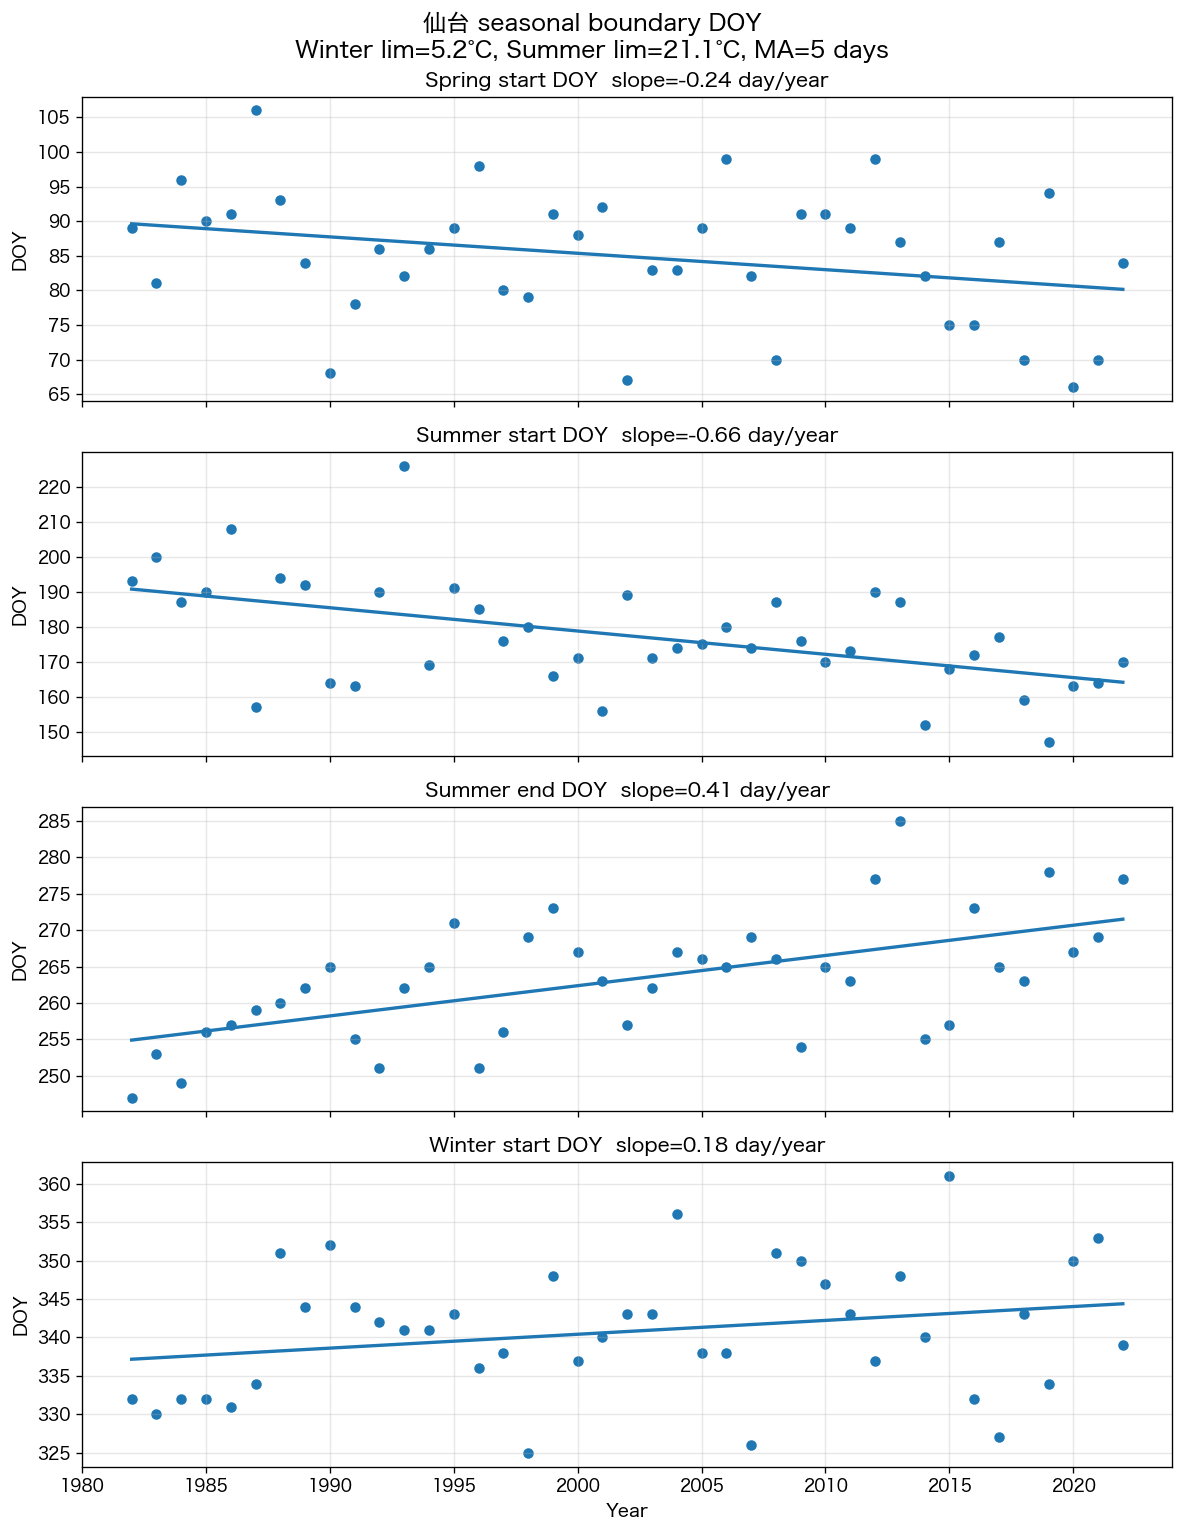

In [32]:
import matplotlib.dates as mdates
import matplotlib as mpl
mpl.rcParams["font.family"] = "Hiragino Sans"   # 日本語フォント指定
mpl.rcParams["axes.unicode_minus"] = False    # －が豆腐になるのを回避

pdf = df_plot.to_pandas()

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})

fig, axes = plt.subplots(4, 1, figsize=(10, 13), sharex=True)

# 春開始
axes[0].scatter(pdf["year"], pdf["spring_start_doy"], s=28)
axes[0].plot(pdf["year"], pdf["spring_start_doy_fit"], lw=2)
axes[0].set_ylabel("DOY")
axes[0].set_title(f"Spring start DOY  slope={slopes['spring_start_doy']:.2f} day/year")
axes[0].grid(True, alpha=0.3)

# 夏開始
axes[1].scatter(pdf["year"], pdf["summer_start_doy"], s=28)
axes[1].plot(pdf["year"], pdf["summer_start_doy_fit"], lw=2)
axes[1].set_ylabel("DOY")
axes[1].set_title(f"Summer start DOY  slope={slopes['summer_start_doy']:.2f} day/year")
axes[1].grid(True, alpha=0.3)

# 夏終了
axes[2].scatter(pdf["year"], pdf["summer_end_doy"], s=28)
axes[2].plot(pdf["year"], pdf["summer_end_doy_fit"], lw=2)
axes[2].set_ylabel("DOY")
axes[2].set_title(f"Summer end DOY  slope={slopes['summer_end_doy']:.2f} day/year")
axes[2].grid(True, alpha=0.3)

# 冬開始
axes[3].scatter(pdf["year"], pdf["winter_start_doy"], s=28)
axes[3].plot(pdf["year"], pdf["winter_start_doy_fit"], lw=2)
axes[3].set_xlabel("Year")
axes[3].set_ylabel("DOY")
axes[3].set_title(f"Winter start DOY  slope={slopes['winter_start_doy']:.2f} day/year")
axes[3].grid(True, alpha=0.3)

fig.suptitle(
    f"{station_name} seasonal boundary DOY\n"
    f"Winter lim={WINTER_LIM:.1f}°C, Summer lim={SUMMER_LIM:.1f}°C, MA={MA_WINDOW} days",
    fontsize=14
)

plt.tight_layout()
fig1_path = cv4.OUTPUT_DIR / f"{station_id}_4season_boundary_doy_{START}_{END}.png"
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

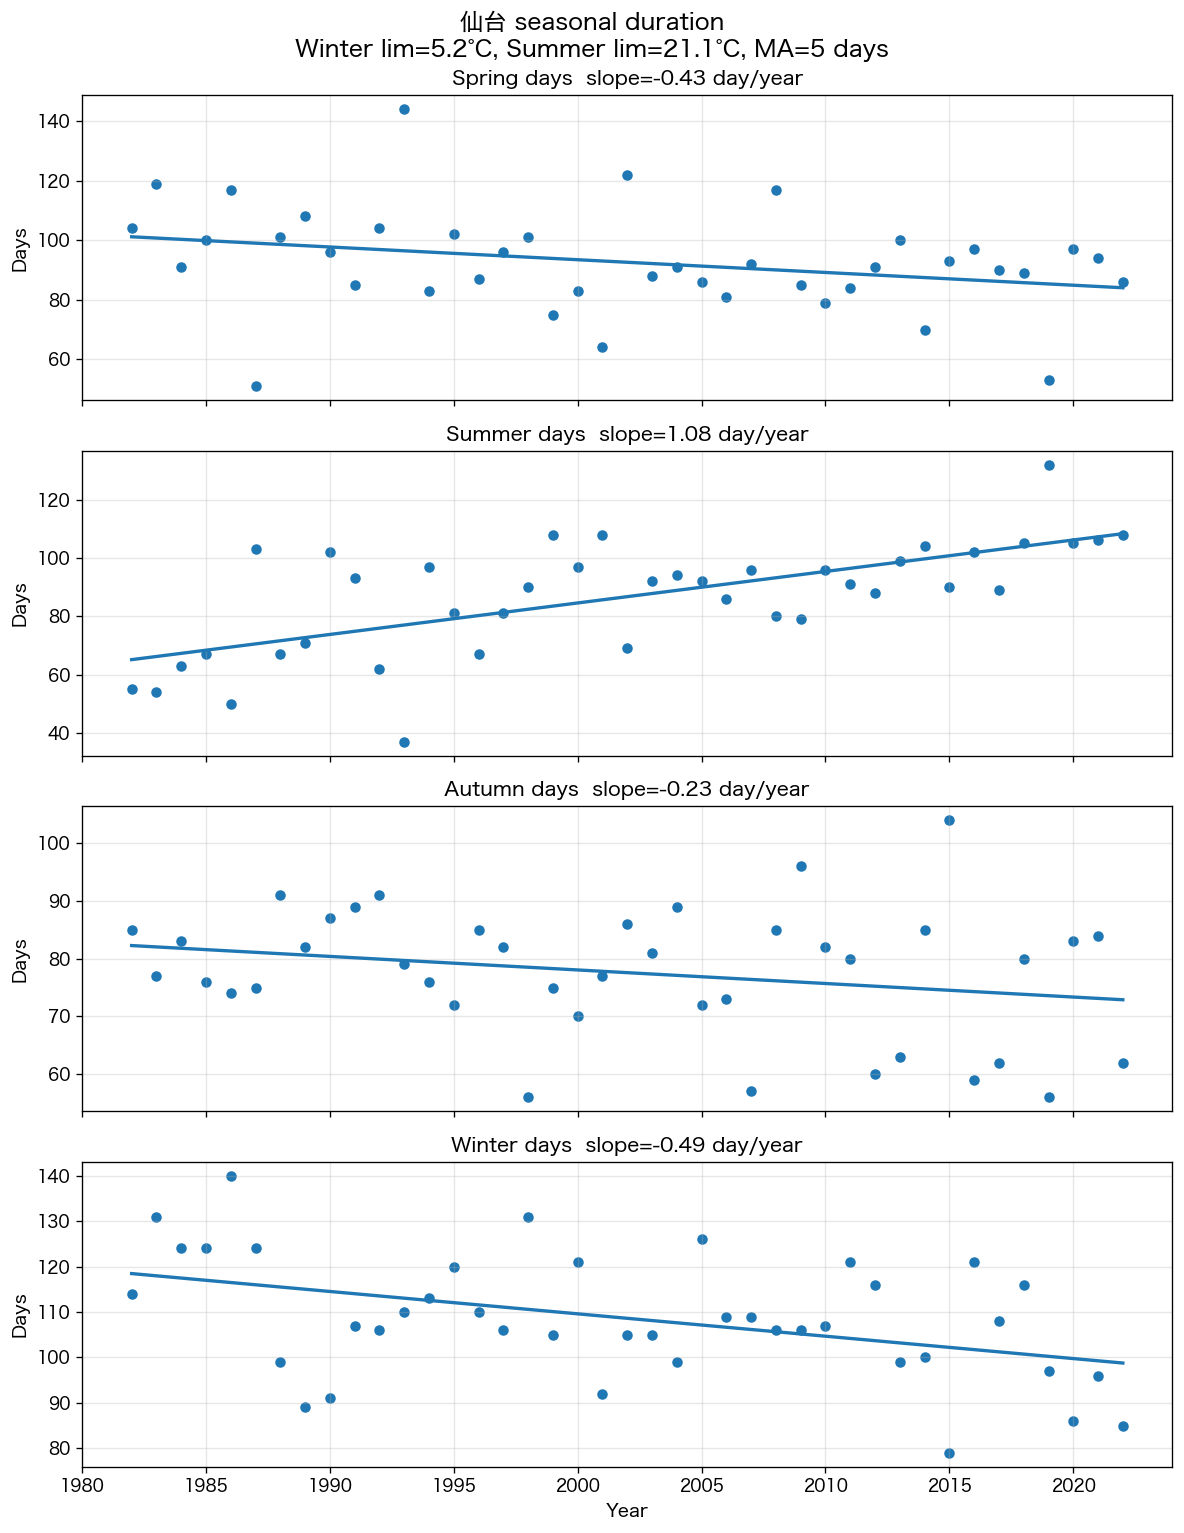

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(10, 13), sharex=True)

# 春
axes[0].scatter(pdf["year"], pdf["spring_days"], s=28)
axes[0].plot(pdf["year"], pdf["spring_days_fit"], lw=2)
axes[0].set_ylabel("Days")
axes[0].set_title(f"Spring days  slope={slopes['spring_days']:.2f} day/year")
axes[0].grid(True, alpha=0.3)

# 夏
axes[1].scatter(pdf["year"], pdf["summer_days"], s=28)
axes[1].plot(pdf["year"], pdf["summer_days_fit"], lw=2)
axes[1].set_ylabel("Days")
axes[1].set_title(f"Summer days  slope={slopes['summer_days']:.2f} day/year")
axes[1].grid(True, alpha=0.3)

# 秋
axes[2].scatter(pdf["year"], pdf["autumn_days"], s=28)
axes[2].plot(pdf["year"], pdf["autumn_days_fit"], lw=2)
axes[2].set_ylabel("Days")
axes[2].set_title(f"Autumn days  slope={slopes['autumn_days']:.2f} day/year")
axes[2].grid(True, alpha=0.3)

# 冬
axes[3].scatter(pdf["year"], pdf["winter_days"], s=28)
axes[3].plot(pdf["year"], pdf["winter_days_fit"], lw=2)
axes[3].set_xlabel("Year")
axes[3].set_ylabel("Days")
axes[3].set_title(f"Winter days  slope={slopes['winter_days']:.2f} day/year")
axes[3].grid(True, alpha=0.3)

fig.suptitle(
    f"{station_name} seasonal duration\n"
    f"Winter lim={WINTER_LIM:.1f}°C, Summer lim={SUMMER_LIM:.1f}°C, MA={MA_WINDOW} days",
    fontsize=14
)

plt.tight_layout()
fig2_path = cv4.OUTPUT_DIR / f"{station_id}_4season_duration_{START}_{END}.png"
fig.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

### 以下、夏限定のコード（過去バージョン）

In [ ]:
temp_wide = df_mean["mean_of_yearly_max"] - df_mean["mean_of_yearly_min"]
temp_lim = df_mean["mean_of_yearly_max"] - (temp_wide / 4)
print(temp_lim)
MA_WINDOW = 5

#station_dir = RAW_ROOT / "daily_monthly" / station_id

lf = (
    pl.scan_parquet(station_dir / f"{station_id}_temp.parquet")
    .filter(pl.col("date").dt.year().is_between(START, END))
)

df_period = (
    lf
    .sort("date")
    .with_columns([
        pl.col("date").dt.year().alias("year"),
        pl.col("date").dt.ordinal_day().alias("doy"),
    ])
    .with_columns([
        pl.col("temp_mean")
        .rolling_mean(window_size=MA_WINDOW, min_samples=MA_WINDOW)
        .over("year")
        .alias("temp_mean_ma5")
    ])
    .group_by("year")
    .agg([
        # 最初に閾値を超えた日
        pl.col("date")
        .filter(pl.col("temp_mean_ma5") > temp_lim)
        .min()
        .alias("first_date"),

        # 最後に閾値を超えた日
        pl.col("date")
        .filter(pl.col("temp_mean_ma5") > temp_lim)
        .max()
        .alias("last_date"),

        # そのDOY
        pl.col("doy")
        .filter(pl.col("temp_mean_ma5") > temp_lim)
        .min()
        .alias("first_doy"),

        pl.col("doy")
        .filter(pl.col("temp_mean_ma5") > temp_lim)
        .max()
        .alias("last_doy"),
    ])
    .with_columns([
        # 期間（日数）
        # 差の日数。両端を含めるなら + 1
        (pl.col("last_date") - pl.col("first_date")).dt.total_days().alias("period_days"),
        ((pl.col("last_date") - pl.col("first_date")).dt.total_days() + 1).alias("period_days_inclusive"),
    ])
    .sort("year")
    .collect()
)

df_period

In [ ]:
df_valid = df_period.drop_nulls(["first_doy", "last_doy", "period_days"])
df_valid

def linear_fit_polars(df: pl.DataFrame, x_col: str, y_col: str) -> tuple[float, float]:
    x = df[x_col].to_list()
    y = df[y_col].to_list()

    n = len(x)
    x_mean = sum(x) / n
    y_mean = sum(y) / n

    sxx = sum((xi - x_mean) ** 2 for xi in x)
    sxy = sum((xi - x_mean) * (yi - y_mean) for xi, yi in zip(x, y))

    slope = sxy / sxx
    intercept = y_mean - slope * x_mean
    return slope, intercept


slope_first, intercept_first = linear_fit_polars(df_valid, "year", "first_doy")
slope_last, intercept_last = linear_fit_polars(df_valid, "year", "last_doy")
slope_period, intercept_period = linear_fit_polars(df_valid, "year", "period_days")

print("first_doy slope   :", slope_first)
print("last_doy slope    :", slope_last)
print("period_days slope :", slope_period)

df_plot = df_valid.with_columns([
    (pl.lit(intercept_first) + pl.lit(slope_first) * pl.col("year")).alias("first_fit"),
    (pl.lit(intercept_last) + pl.lit(slope_last) * pl.col("year")).alias("last_fit"),
    (pl.lit(intercept_period) + pl.lit(slope_period) * pl.col("year")).alias("period_fit"),
])

df_plot



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
mpl.rcParams["font.family"] = "Hiragino Sans"   # 例：Noto Sans CJK JP でも可
mpl.rcParams["axes.unicode_minus"] = False    # －が豆腐になるのを回避

pdf = df_plot.to_pandas()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 開始日
axes[0].scatter(pdf["year"], pdf["first_doy"])
axes[0].plot(pdf["year"], pdf["first_fit"])
axes[0].set_ylabel("First DOY")
axes[0].set_title(f"{station_name}  閾値分析: ({MA_WINDOW}日移動平均)")
axes[0].grid(True)

# 終了日
axes[1].scatter(pdf["year"], pdf["last_doy"])
axes[1].plot(pdf["year"], pdf["last_fit"])
axes[1].set_ylabel("Last DOY")
axes[1].grid(True)

# 期間
axes[2].scatter(pdf["year"], pdf["period_days"])
axes[2].plot(pdf["year"], pdf["period_fit"])
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Period (days)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig(cv4.OUTPUT_DIR / f"閾値分析（夏の長さ）_{station_name}.png")

plt.show()
